In [1]:
from IPython.display import HTML, display

def create_banner(text, bg_color, text_color="white", font_size="24px"):
    html = f"""
    <div style="
        background-color: {bg_color};
        color: {text_color};
        padding: 20px;
        text-align: center;
        font-size: {font_size};
        border-radius: 10px;
    ">
        {text}
    </div>
    """
    display(HTML(html))

In [2]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# Load images using public URLs to display them in the notebook
def load_public_image(image_url, figsize=(7, 7)):
    """
    Load and display an image from a public URL in the notebook.
    
    Parameters:
    - image_url: str, the URL of the image.
    - figsize: tuple, the size of the displayed image (width, height).
    """
    response = requests.get(image_url)
    img = Image.open(BytesIO(response.content))

    # Create the figure
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    ax.axis('off')
    
    # Render the figure to a temporary file
    plt.tight_layout()
    plt.savefig('temp_img.png', bbox_inches='tight', pad_inches=0)
    plt.close(fig)

    # Center-align the image in the notebook
    display(HTML(f"""
    <div style="display: flex; justify-content: center;">
        <img src="temp_img.png" style="max-width: 100%; height: auto;">
    </div>
    """))


In [3]:
create_banner("1. Introduction", bg_color="#5A92D6")

In [4]:
load_public_image("https://gitlab.com/jex-projects/mrjex/-/raw/main/readme-material/joel-banner.png?ref_type=heads&inline=false", figsize=(12, 6))

## Machine Learning Project - January 2025
The course "Foundations of Machine Learning" is an integral part of a broader module that also includes "Foundations of Artificial Intelligence." While the AI course primarily focused on classification and clustering using the MNIST database, the Machine Learning course emphasizes neural networks for classification, incorporating aspects of information theory. These courses were conducted from September 2024 to January 2025.


### Project Description
This project focuses on image classification using a Kaggle dataset: Food Classification Dataset. The primary goal was to achieve the highest possible classification accuracy by leveraging a neural network. To accomplish this, I implemented the following key components:

* **Convolutional Neural Network (InceptionV3):** Utilized a pre-trained model for feature extraction and classification.
* **Softmax Activation Function:** Applied for probabilistic outputs in the classification layer.
* **Cross-Entropy Loss Function:** Used as the objective function to minimize during training.
* **Adam Optimizer:** Employed to efficiently update model weights during optimization.
* **L2 Regularization:** Added to reduce overfitting by penalizing large weights.
* **Fine-Tuning:** Enabled further optimization of specific layers for improved performance.
* **Dropout:** Introduced to prevent overfitting by randomly deactivating neurons during training.
* **Data Augmentation:** Enhanced model generalization by generating diverse training samples.
* **Early Stopping:** Monitored validation performance to halt training when improvements plateaued



#### Dataset

* 6500 images in total with uniform distribution across all 13 classes
* The classes are all Indonesian foods
* Although this is the only external dataset, other images from ImageNet are used in the freezed layers as a way of leveraging fine-tuning for saving computational resources




### Table of Contents

1. Introduction
2. Import Libraries
3. Data Exploration
4. Preprocessing
5. Model Training
6. Model Fine-Tuning
7. Model Evaluation

In [5]:
create_banner("2. Import Libraries", bg_color="#5A92D6")

In [6]:
import os
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping
from tensorflow.keras.mixed_precision import set_global_policy
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.image as mpimg

import seaborn as sns
import numpy as np
import time

# Suppress unnecessary logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Enable mixed precision training
set_global_policy('mixed_float16')

# Debug mode configuration
DEBUG_MODE = True


# Note that 'train_subset' and 'valid_subet' represent the number of images for EACH class.
# As there are a total of 13 classes, the total amount of images that these two variables
# respectively cover is multiplied by 13.


'''
# Time: 10 min, 77.6% accuracy
config = {
    'train_subset': 3000 if DEBUG_MODE else None,
    'valid_subset': 750 if DEBUG_MODE else None,
    'epochs': 15 if DEBUG_MODE else 20,
    'batch_size': 16 if DEBUG_MODE else 32,
    'img_size': (128, 128) if DEBUG_MODE else (224, 224),
    'fine_tune_layers': 35 if DEBUG_MODE else 50,
    'dense_units': 512 if DEBUG_MODE else 1024,
}
'''


'''
# Time: 7 min, 75% accuracy
config = {
    'train_subset': 1800 if DEBUG_MODE else None,
    'valid_subset': 200 if DEBUG_MODE else None,
    'epochs': 10 if DEBUG_MODE else 20,
    'batch_size': 16 if DEBUG_MODE else 32,
    'img_size': (128, 128) if DEBUG_MODE else (224, 224),
    'fine_tune_layers': 30 if DEBUG_MODE else 50,
    'dense_units': 512 if DEBUG_MODE else 1024,
}
'''

'''
# Time: 5 min, 60% accuracy
config = {
    'train_subset': 400 if DEBUG_MODE else None,
    'valid_subset': 100 if DEBUG_MODE else None,
    'epochs': 6 if DEBUG_MODE else 20,
    'batch_size': 16 if DEBUG_MODE else 32,
    'img_size': (128, 128) if DEBUG_MODE else (224, 224),
    'fine_tune_layers': 20 if DEBUG_MODE else 50,
    'dense_units': 512 if DEBUG_MODE else 1024
}
'''

# Time: 2 min, 13% accuracy
config = {
    'train_subset': 80 if DEBUG_MODE else None,
    'valid_subset': 20 if DEBUG_MODE else None,
    'epochs': 3 if DEBUG_MODE else 20,
    'batch_size': 16 if DEBUG_MODE else 32,
    'img_size': (128, 128) if DEBUG_MODE else (224, 224),
    'fine_tune_layers': 10 if DEBUG_MODE else 50,
    'dense_units': 512 if DEBUG_MODE else 1024,
}



# Define directories
base_dir = '/kaggle/input/dataset-food-classification/dataset_gambar'
train_dir = os.path.join(base_dir, 'train')
valid_dir = os.path.join(base_dir, 'valid')
test_dir = os.path.join(base_dir, 'test')

In [7]:
create_banner("3. Data Exploration", bg_color="#5A92D6")

In [8]:
def get_folders(directory):
    """
    Retrieve a sorted list of folders in the specified directory.
    Args:
        directory (str): Path to the directory containing folders.
    Returns:
        list: Sorted list of folder names.
    """
    return sorted([folder for folder in os.listdir(directory) if os.path.isdir(os.path.join(directory, folder))])


def plot_images_from_folders(folders, train_dir, max_rows=2, max_cols=7):
    """
    Plots the first image from each folder in the train directory.
    Args:
        folders (list): List of folder names.
        train_dir (str): Path to the train directory containing image folders.
        max_rows (int): Maximum number of rows in the subplot.
        max_cols (int): Maximum number of columns in the subplot.
    """
    # Initialize a figure for subplots
    fig, axes = plt.subplots(max_rows, max_cols, figsize=(20, 10))
    axes = axes.flatten()  # Flatten axes array for easy indexing

    # Loop through each folder and plot the first image
    for i, folder in enumerate(folders):
        folder_path = os.path.join(train_dir, folder)
        images = sorted([img for img in os.listdir(folder_path) if img.endswith('.jpg')])

        if images:
            img_path = os.path.join(folder_path, images[0])
            img = mpimg.imread(img_path)
            axes[i].imshow(img)
            axes[i].set_title(folder, fontsize=10)
            axes[i].axis('off')

    # Hide unused axes
    for ax in axes[len(folders):]:
        ax.remove()

    # Adjust layout and display the plot
    plt.tight_layout()
    plt.show()

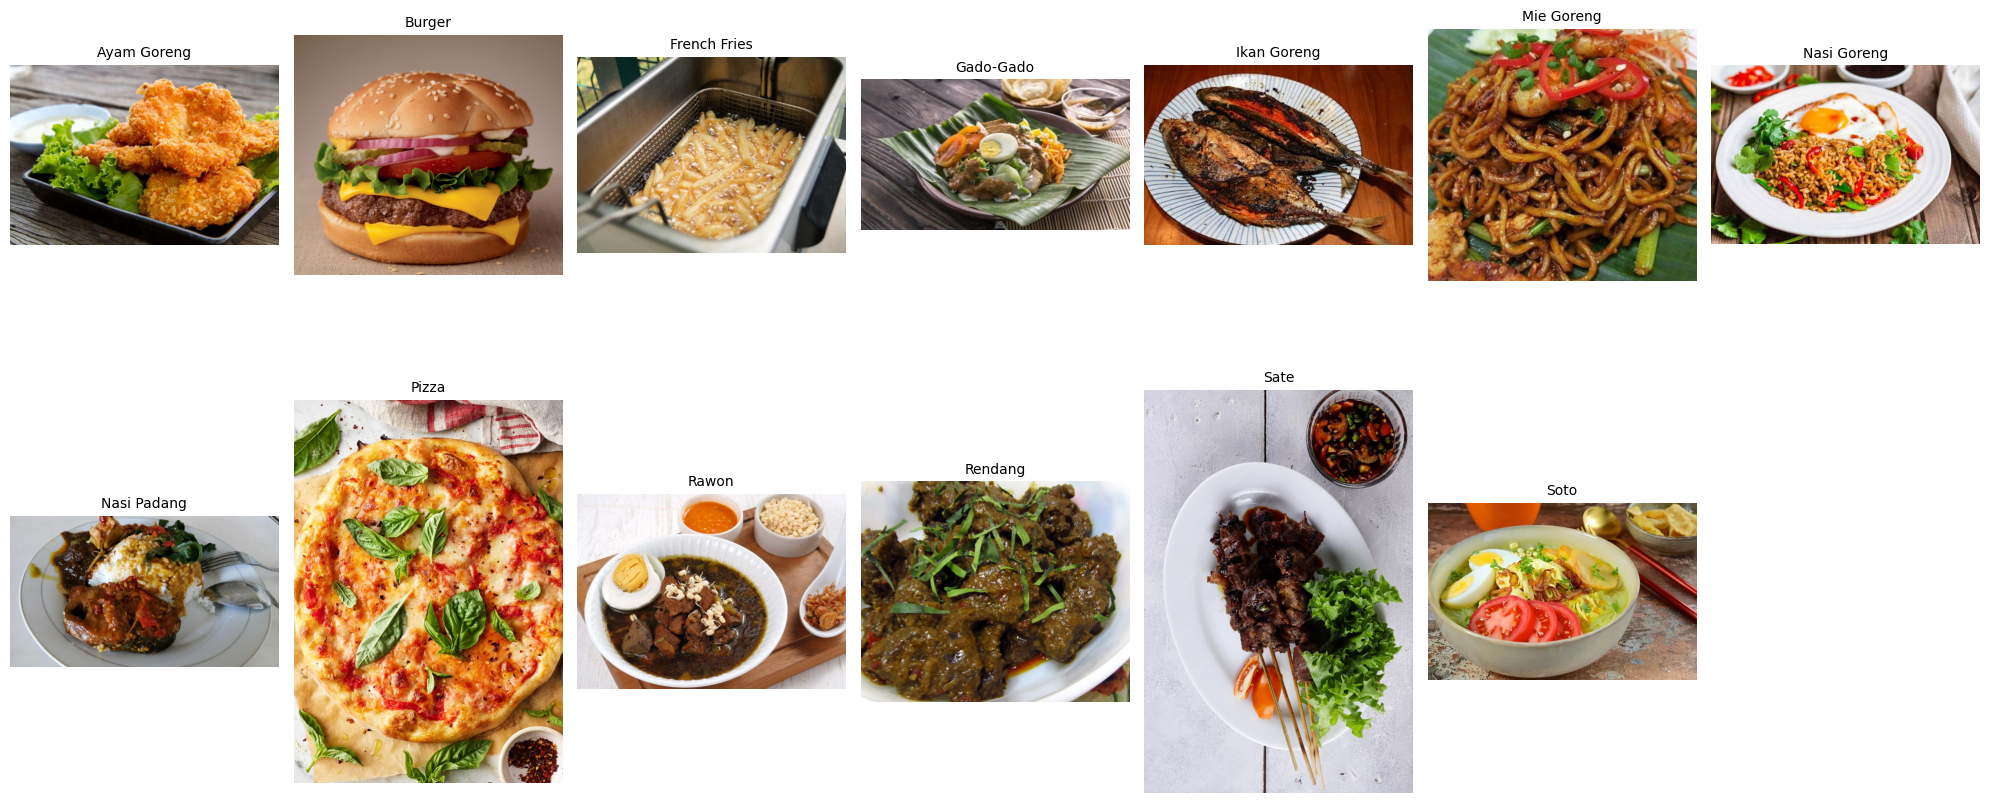

In [9]:
folders = get_folders(train_dir)
plot_images_from_folders(folders, train_dir)

In [10]:
##  Define front-end visualization functions  ##

def plot_pie_chart(counts_per_split, splits, food_classes):
    """
    Plots pie charts for the distribution of samples across splits as subplots.
    
    Args:
        counts_per_split: Dictionary with class counts for each split.
        splits: List of dataset splits (e.g., train, test, valid).
        food_classes: List of food class names.
    """
    
    fig, axes = plt.subplots(1, len(splits), figsize=(18, 6))
    for ax, split in zip(axes, splits):
        sizes = counts_per_split[split]
        ax.pie(sizes, labels=food_classes, autopct='%1.1f%%', startangle=140)
        ax.set_title(f"Class Distribution in {split.capitalize()} Split")
        ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.tight_layout()
    plt.show()




def plot_stacked_bar_chart(counts_per_split, food_classes, splits):
    """
    Plots a stacked bar chart for class distributions across splits with values in the middle of each bar.
    
    Args:
        counts_per_split: Dictionary with class counts for each split.
        food_classes: List of food class names.
        splits: List of dataset splits (e.g., train, test, valid).
    """

    class_counts = np.array([counts_per_split[split] for split in splits])
    x = np.arange(len(food_classes))
    bar_width = 0.6

    bottom = np.zeros(len(food_classes))
    plt.figure(figsize=(10, 6))
    for i, split in enumerate(splits):
        bars = plt.bar(
            x,
            class_counts[i],
            bar_width,
            label=split.capitalize(),
            bottom=bottom,
        )
        for bar, count in zip(bars, class_counts[i]):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() / 2 + bar.get_y(),
                str(int(count)),
                ha='center',
                va='center',
                fontsize=9,
                color='white'
            )
        bottom += class_counts[i]

    plt.xlabel("Food Classes")
    plt.ylabel("Counts")
    plt.title("Class Distributions Across Splits")
    plt.xticks(x, food_classes, rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()



def plot_class_distributions(counts_per_split, food_classes, splits):
    """
    Wrapper function to call pie chart and stacked bar chart plotting functions.
    
    Args:
        counts_per_split: Dictionary with class counts for each split.
        food_classes: List of food class names.
        splits: List of dataset splits (e.g., train, test, valid).
    """
    plot_pie_chart(counts_per_split, splits, food_classes)
    plot_stacked_bar_chart(counts_per_split, food_classes, splits)


In [11]:
def get_food_classes():
    """
    Returns a list of food classes.
    """
    return [
        "Ayam Goreng", "Burger", "French Fries", "Gado-Gado", "Ikan Goreng",
        "Nasi Goreng", "Nasi Padang", "Mie Goreng", "Pizza", "Rawon",
        "Rendang", "Sate", "Soto"
    ]

def get_image_counts(dataset_dir, splits, food_classes, config):
    """
    Retrieves the number of images for each split and class.
    Args:
        dataset_dir (str): Path to the dataset directory.
        splits (list): List of dataset splits (e.g., train, test, valid).
        food_classes (list): List of food class names.
        config (dict): Configuration for subset limits.
    Returns:
        dict: Counts of images per split and class.
    """
    counts_per_split = {split: [] for split in splits}
    print('Number of images')

    for split in splits:
        print(f'\nSplit: {split}')
        split_path = os.path.join(dataset_dir, split)
        if not os.path.isdir(split_path):
            print(f"Folder '{split}' not found.")
            continue

        for food_type in food_classes:
            food_path = os.path.join(split_path, food_type)
            if os.path.isdir(food_path):  
                image_files = [f for f in os.listdir(food_path) if os.path.isfile(os.path.join(food_path, f))]

                # Apply subset limits if debug mode is enabled
                subset_limit = config['train_subset'] if split == 'train' else config['valid_subset']
                if subset_limit:
                    image_files = image_files[:subset_limit // len(food_classes)]

                counts_per_split[split].append(len(image_files))
                print(f'  {food_type}: {len(image_files)}')
            else:
                counts_per_split[split].append(0)
                print(f'  Folder {food_type} not found in split {split}.')
    
    return counts_per_split

Number of images

Split: train
  Ayam Goreng: 400
  Burger: 400
  French Fries: 400
  Gado-Gado: 400
  Ikan Goreng: 400
  Nasi Goreng: 400
  Nasi Padang: 400
  Mie Goreng: 400
  Pizza: 400
  Rawon: 400
  Rendang: 400
  Sate: 400
  Soto: 400

Split: test
  Ayam Goreng: 50
  Burger: 50
  French Fries: 50
  Gado-Gado: 50
  Ikan Goreng: 50
  Nasi Goreng: 50
  Nasi Padang: 50
  Mie Goreng: 50
  Pizza: 50
  Rawon: 50
  Rendang: 50
  Sate: 50
  Soto: 50

Split: valid
  Ayam Goreng: 50
  Burger: 50
  French Fries: 50
  Gado-Gado: 50
  Ikan Goreng: 50
  Nasi Goreng: 50
  Nasi Padang: 50
  Mie Goreng: 50
  Pizza: 50
  Rawon: 50
  Rendang: 50
  Sate: 50
  Soto: 50


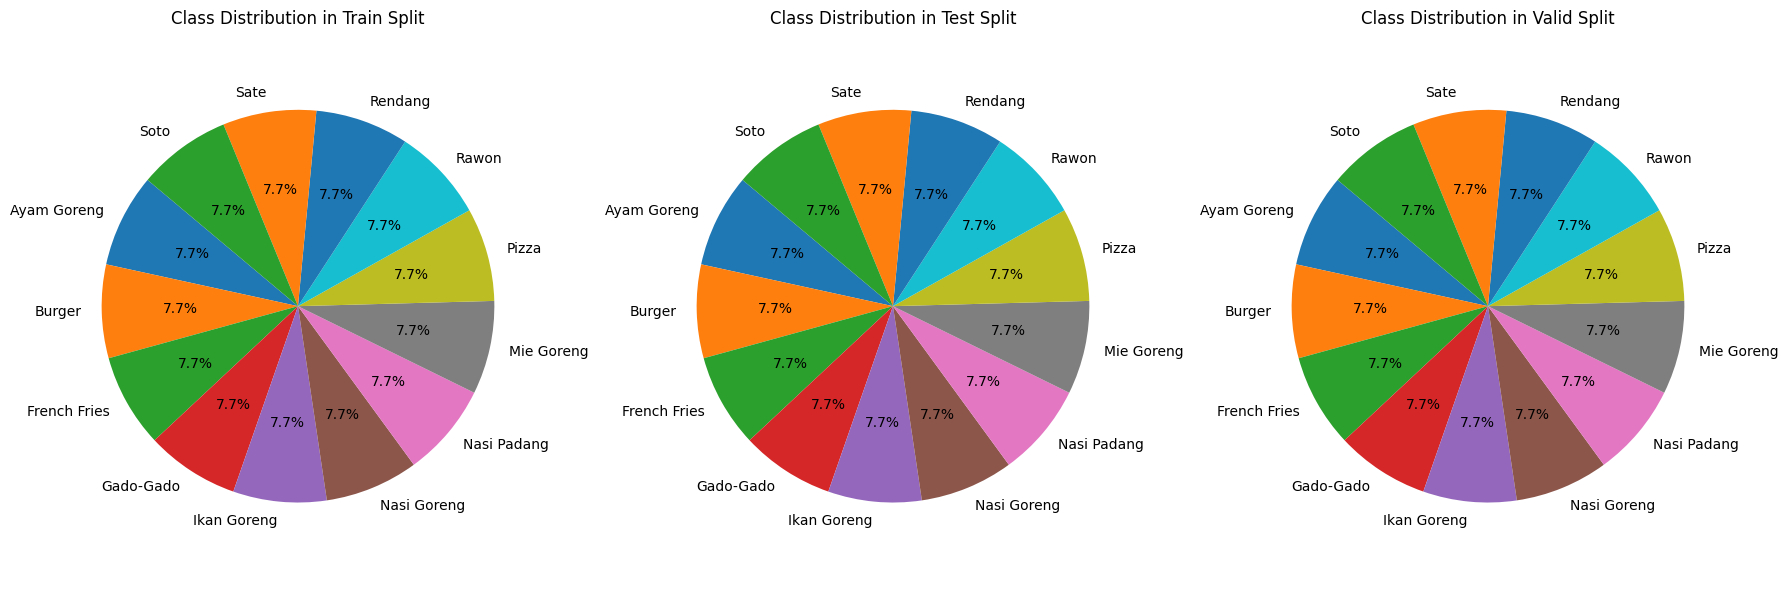

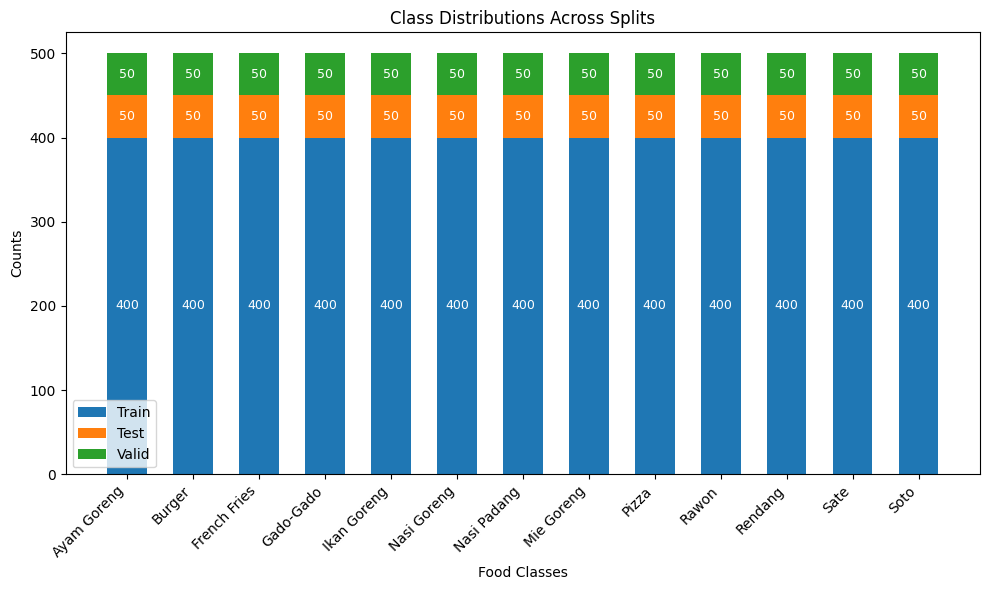

In [12]:
splits = ['train', 'test', 'valid']

food_classes = get_food_classes()
counts_per_split = get_image_counts(base_dir, splits, food_classes, config)
plot_class_distributions(counts_per_split, food_classes, splits)

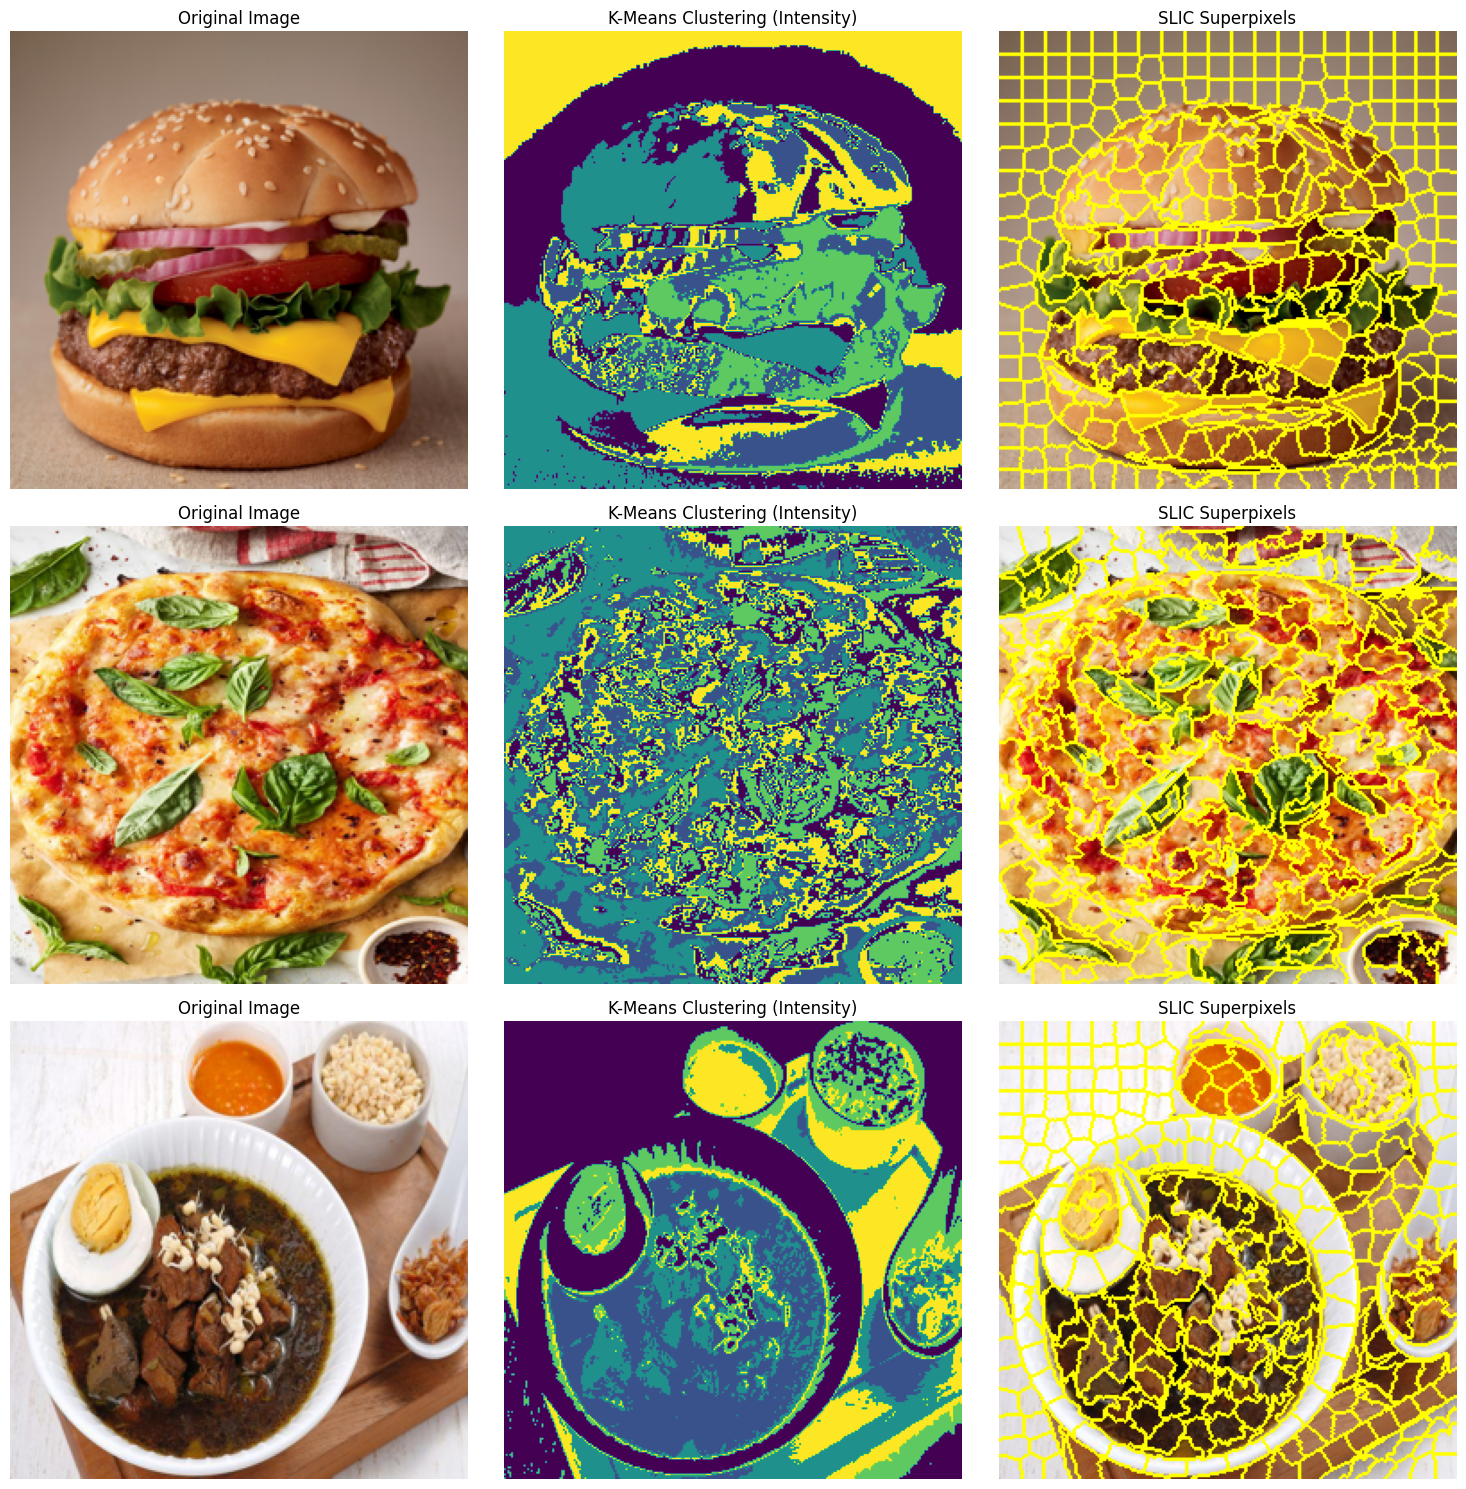

In [13]:
from sklearn.cluster import KMeans
from skimage.color import rgb2gray
from skimage.segmentation import slic, mark_boundaries, find_boundaries
import networkx as nx


# Create a region adjacency graph (RAG) using networkx
def create_rag(image, superpixels):
    g = nx.Graph()
    boundaries = find_boundaries(superpixels, mode='outer')

    unique_labels = np.unique(superpixels)
    for label in unique_labels:
        mask = (superpixels == label) & boundaries
        neighbors = np.unique(superpixels[mask])
        for neighbor in neighbors:
            if neighbor != label:  # Avoid self-loops
                g.add_edge(label, neighbor)

    return g

# Load and preprocess images for clustering (using SLIC segmentation)
def cluster_image(image, n_clusters=5, compactness=10):
    gray_image = rgb2gray(image)
    flat_gray = gray_image.flatten()

    # Perform K-Means clustering on intensity
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    gray_labels = kmeans.fit_predict(flat_gray.reshape(-1, 1))
    clustered_image = gray_labels.reshape(gray_image.shape)

    # Perform superpixel segmentation with SLIC
    superpixels = slic(image, n_segments=400, compactness=compactness, start_label=1)
    rag = create_rag(image, superpixels)

    return clustered_image, superpixels

# Function to process multiple images and display in a grid
def process_multiple_images(image_paths):
    fig, axes = plt.subplots(len(image_paths), 3, figsize=(15, 5 * len(image_paths)))

    for i, image_path in enumerate(image_paths):
        image = np.array(Image.open(image_path).resize((256, 256)))

        # Perform clustering
        clustered_image, superpixels = cluster_image(image)

        # Plot results for each image
        axes[i, 0].imshow(image)
        axes[i, 0].set_title("Original Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(clustered_image, cmap='viridis')
        axes[i, 1].set_title("K-Means Clustering (Intensity)")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(mark_boundaries(image, superpixels))
        axes[i, 2].set_title("SLIC Superpixels")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

# Example usage with three images
image_paths = [
    "/kaggle/input/dataset-food-classification/dataset_gambar/train/Burger/Burger_001.jpg",
    "/kaggle/input/dataset-food-classification/dataset_gambar/train/Pizza/Pizza_001.jpg",
    "/kaggle/input/dataset-food-classification/dataset_gambar/train/Rawon/Rawon_001.jpg"
]

process_multiple_images(image_paths)


### How SLIC and Normalized Cut are Related

#### SLIC as Preprocessing:

SLIC superpixels can be used as input to Normalized Cut.
Instead of constructing a graph at the pixel level (which is computationally expensive), Normalized Cut can operate on superpixels generated by SLIC. Each superpixel is treated as a node in the graph.

#### Graph Construction:

SLIC simplifies the graph construction for Normalized Cut by reducing the number of nodes (from pixels to superpixels), making the process faster and more scalable.

In [14]:
create_banner("4. Preprocessing", bg_color="#5A92D6")

In [15]:
# Data generators with augmentation for preprocessing
train_data_gen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_data_gen = ImageDataGenerator(rescale=1.0/255.0)

train_gen = train_data_gen.flow_from_directory(
    train_dir,
    target_size=config['img_size'],
    batch_size=config['batch_size'],
    class_mode='categorical',
    shuffle=True
)

valid_gen = valid_data_gen.flow_from_directory(
    valid_dir,
    target_size=config['img_size'],
    batch_size=config['batch_size'],
    class_mode='categorical'
)

test_gen = valid_data_gen.flow_from_directory(
    test_dir,
    target_size=config['img_size'],
    batch_size=config['batch_size'],
    class_mode='categorical',
    shuffle=False
)

Found 5193 images belonging to 13 classes.
Found 650 images belonging to 13 classes.
Found 648 images belonging to 13 classes.


In [16]:
# Adjust subset sizes
if config['train_subset']:
    train_gen.samples = config['train_subset']

if config['valid_subset']:
    valid_gen.samples = config['valid_subset']

def get_steps(generator):
    return max(1, generator.samples // config['batch_size'])

# Learning rate scheduler
def lr_schedule(epoch, lr):
    if epoch > 5:
        return lr * 0.5
    return lr

lr_scheduler = LearningRateScheduler(lr_schedule)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

### Learning Rate Scheduler
- *Adjusts the learning rate during training based on a predefined schedule*
- *Speed up convergence by using higher learning rates early in training. Prevent overshooting or oscillations in later epochs by reducing the learning rate gradually*
- *A well-designed learning rate schedule can lead to **better optimization** and **improved final model accuracy***


### Early Stopping
- *Monitors a specific metric (in this case, validation loss val_loss) during training and stops training if the metric doesn't improve for a certain number of epochs*
- ***Prevents overfitting** by stopping training when the validation performance stops improving*
- ***Saves computational resources** by stopping unnecessary epochs when the model has already reached its peak performance*

In [17]:
create_banner("5. Model Training", bg_color="#5A92D6")

In [18]:
# Load the pre-trained InceptionV3 model without the top layer
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(config['img_size'][0], config['img_size'][1], 3))


##  Regularization techniques - Prevent overfitting  ##
#  - Dropout Layers: Add dropout in the custom dense layers
#  - L2 Regularization: Apply L2 regularization to dense layers

# Add custom layers on top of InceptionV3
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(config['dense_units'], activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
output = Dense(len(train_gen.class_indices), activation='softmax')(x)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Define the final model
model = Model(inputs=base_model.input, outputs=output)

# Freeze the base model's layers for initial training
for layer in base_model.layers[:-config['fine_tune_layers']]:
    layer.trainable = False

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=config['epochs'],
    steps_per_epoch=min(config['train_subset'] // config['batch_size'], get_steps(train_gen)) if config['train_subset'] else get_steps(train_gen),
    validation_steps=min(config['valid_subset'] // config['batch_size'], get_steps(valid_gen)) if config['valid_subset'] else get_steps(valid_gen),
    callbacks=[lr_scheduler, early_stopping]
)

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


153/162 ━━━━━━━━━━━━━━━━━━━━ 7s 832ms/step - accuracy: 0.4775 - loss: 14.6135

In [ ]:
create_banner("6. Model Fine-Tuning", bg_color="#5A92D6")

In [ ]:
##  Inspect layers for Fine-tuning  ##

# Fine-tune the model (unfreeze some layers of the base model)
for layer in base_model.layers[-config['fine_tune_layers']:]:
    if isinstance(layer, tf.keras.layers.Layer):  # Ensure it's a valid layer
        layer.trainable = True

'''
Additional Tip: Checking the Model Layers
To better understand how layers are structured, you can inspect the layers in the model.
This will help confirm which layers you want to fine-tune.
'''
for i, layer in enumerate(base_model.layers):
    print(f"Layer {i}: {layer.name}, Trainable: {layer.trainable}")

## Interpretation of the layers displayed above

As can be seen, most of the layers aren't trainable, as denoted by `Trainable: False` from *Layer 0* to *Layer 290*.

In [ ]:
##  Fine-tune model  ##

# Recompile the model for fine-tuning
model.compile(optimizer=Adam(learning_rate=0.00001), loss='categorical_crossentropy', metrics=['accuracy'])

# Fine-tuning
history_fine = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=config['epochs'],
    steps_per_epoch=min(config['train_subset'] // config['batch_size'], get_steps(train_gen)) if config['train_subset'] else get_steps(train_gen),
    validation_steps=min(config['valid_subset'] // config['batch_size'], get_steps(valid_gen)) if config['valid_subset'] else get_steps(valid_gen),
    callbacks=[lr_scheduler, early_stopping]
)

In [ ]:
create_banner("7. Model Evaluation", bg_color="#5A92D6")

In [ ]:
# Class-wise metrics
y_true = test_gen.classes
y_pred = np.argmax(model.predict(test_gen), axis=-1)
print(classification_report(y_true, y_pred, target_names=test_gen.class_indices.keys()))


# Assuming the following variables are available:
# class_names: List of class labels
# y_true: True labels from test_gen.classes
# y_pred: Predicted labels from the model
# conf_matrix: Confusion matrix generated from y_true and y_pred
# report: Classification report as a dictionary (output_dict=True in classification_report)

# Class names for the chart (example; replace with actual)
class_names = [
    "Ayam Goreng", "Burger", "French Fries", "Gado-Gado", "Ikan Goreng", "Mie Goreng",
    "Nasi Goreng", "Nasi Padang", "Pizza", "Rawon", "Rendang", "Sate", "Soto"
]


report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True) # Generate the classification report as a dictionary

# Extract precision, recall, and F1-score for visualization
metrics = ["precision", "recall", "f1-score"]
class_wise_metrics = {metric: [report[class_name][metric] for class_name in class_names] for metric in metrics}

# Colors for grouped bar chart
colors = sns.color_palette("coolwarm", 3)

# Grouped bar chart for Precision, Recall, and F1-Score
x = np.arange(len(class_names))  # x locations for classes
width = 0.25  # Width of each bar

plt.figure(figsize=(16, 8))
for i, metric in enumerate(metrics):
    plt.bar(x + i * width, class_wise_metrics[metric], width, label=metric.capitalize(), color=colors[i])

plt.title("Class-wise Metrics (Precision, Recall, F1-Score)", fontsize=18)
plt.xlabel("Class Names", fontsize=14)
plt.ylabel("Metric Value", fontsize=14)
plt.xticks(x + width, class_names, rotation=45, ha="right", fontsize=12)
plt.ylim(0, 1)
plt.legend(title="Metric", fontsize=12, title_fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_gen)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')

In [ ]:
# Accuracy visualization (overall and per class)
overall_accuracy = test_accuracy  # Use the variable from model evaluation
recall_per_class = class_wise_metrics["recall"]  # Recall is equivalent to class-specific accuracy

# Plot overall accuracy as a horizontal bar
plt.figure(figsize=(8, 4))
plt.barh(["Overall Accuracy"], [overall_accuracy], color="skyblue")
plt.xlim(0, 1)
plt.title("Overall Model Accuracy", fontsize=16)
plt.xlabel("Accuracy", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Overall Model Accuracy: {overall_accuracy:.2f}")

In [ ]:
# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Confusion matrix with red palette
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Reds", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted", fontsize=14)
plt.ylabel("Actual", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Measure inference time
start_time = time.time()
model.predict(test_gen)
inference_time = time.time() - start_time
latency = inference_time / len(test_gen)
throughput = len(test_gen) / inference_time

print(f"Inference Time - Latency: {latency:.4f} seconds per sample")
print(f"Inference Time - Throughput: {throughput:.2f} samples per second")

In [ ]:
# Model size
model.save('/kaggle/working/inceptionv3_food_classifier.h5')
model_size = os.path.getsize('/kaggle/working/inceptionv3_food_classifier.h5') / (1024 ** 2)
print(f"Model Size: {model_size:.2f} MB")

In [ ]:
# Visualize training performance
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()